In [29]:
from scipy.optimize import minimize
from scipy.integrate import solve_ivp
from scipy.interpolate import CubicSpline

import numpy as np
import matplotlib.pyplot as plt

from dataclasses import dataclass

import numba as nb
import numba.experimental as nbe

from typing import Callable, Tuple

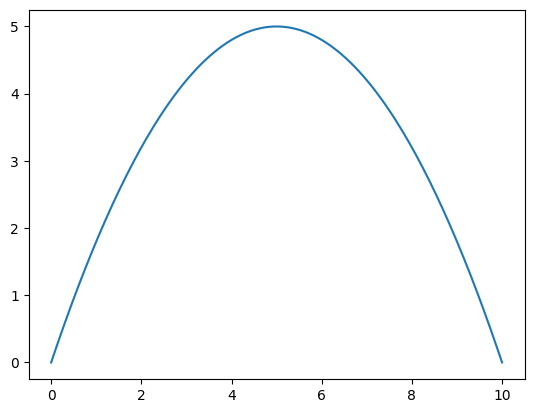

In [2]:
t_final = 20.0
dt = 0.1

num_samples = int(t_final / dt)

spline_method = CubicSpline

t = np.linspace(0, t_final, num_samples)
path_points = np.array([(0.0, 0.0, 0.0), (5.0, 5.0, t_final / 2), (10.0, 0.0, t_final)])

# generators for the spline
x_spline, y_spline = (
    spline_method(path_points[:, 2], path_points[:, 0]),
    spline_method(path_points[:, 2], path_points[:, 1]),
)

# computes the array indices
x_traj, y_traj = (
    x_spline(t),
    y_spline(t),
)
theta_traj = np.atan2(y_traj, x_traj)


# generates a lookup handle
def traj(t):
    closest_idx = int(round(t / dt))
    return (x_traj[closest_idx], y_traj[closest_idx], theta_traj[closest_idx])


fig, ax = plt.subplots()
ax.plot(x_traj, y_traj)
plt.show()

In [36]:
def _mpc_cost(t, y, u_steps, dt, params, model_step, state_cost):
    # do not consider the current cost
    num_steps = u_steps.shape[0]

    total_cost = 0
    y_upd = y

    for i in range(num_steps):
        u = u_steps[i, :]
        t_upd = t + dt * i

        y_upd = model_step(t_upd, dt, y_upd, u, params)
        total_cost += state_cost(t_upd, y_upd, u, i, params)

    return total_cost


def gen_mpc_controls(
    t, y, steps, dt, u_guess: np.ndarray, params, model_step, state_cost
):
    # must find inputs over finite time horizon that minimize the total cost

    # repeats the guess then flattens to be able to use as variable for minimize
    u_steps_guess = np.repeat(
        u_guess.reshape((1, len(u_guess))), steps, axis=0
    ).flatten()

    result = minimize(
        lambda u_steps: _mpc_cost(
            t,
            y,
            u_steps.reshape((steps, len(u_guess))),  # each step as row
            dt,
            params,
            model_step,
            state_cost,
        ),
        u_steps_guess,
    )

    if not result.success:
        print("Failed to fully converge at solution, is suboptimal")

    result_u_steps = result.x.reshape((steps, len(u_guess)))
    return (result_u_steps[0, :], result_u_steps)

In [37]:
def dyn_ext_unicycle_cost(t, y, u, k, params):
    x, y, theta, v, omega = y
    x_traj, y_traj, theta_traj = params.traj_gen(t)

    state_cost = (
        0.5 * params.dist_cost * ((x_traj - x) ** 2 + (y_traj - y) ** 2)
        + 0.5 * params.ang_cost * (theta - theta_traj) ** 2
    )

    input_cost = u.T @ params.u_cost @ u

    return params.fut_pred_factor(k) * state_cost + input_cost


def dyn_ext_unicycle_model_step(t, dt, y, u, params):
    u_f, u_t = u

    def model_f(t, y):
        _, _, theta, v, omega = y
        return np.array([v * np.cos(theta), v * np.sin(theta), omega, u_f, u_t])

    result = solve_ivp(model_f, [0, dt], y)
    return result.y[:, -1]


@dataclass
class DynExtUnicycleMCPParams:
    dist_cost = 5.0
    ang_cost = 1.0
    u_cost = 0.5 * np.identity(2)
    traj_gen = traj
    fut_pred_factor = lambda k: 1.0 * k if k > 0 else 1.0

In [38]:
p0 = np.array([0.0, 0.0, np.pi / 2, 0.0, 0.0])  # pointing straight up

u_mpc = gen_mpc_controls(
    0.0,
    p0,
    10,
    dt,
    np.zeros((2,)),
    DynExtUnicycleMCPParams,
    dyn_ext_unicycle_model_step,
    dyn_ext_unicycle_cost,
)

u_mpc

(array([ 2.39000377, -1.65280567]),
 array([[ 2.39000377, -1.65280567],
        [ 2.10941527, -1.3134907 ],
        [ 1.81828683, -1.00157002],
        [ 1.51664989, -0.72260984],
        [ 1.2102973 , -0.4866214 ],
        [ 0.9093435 , -0.29951876],
        [ 0.62689956, -0.16272375],
        [ 0.37804993, -0.0731686 ],
        [ 0.1791242 , -0.02368634],
        [ 0.04723578, -0.00369205]]))

In [45]:
# implement the control loop

p0 = np.array([0.0, 0.0, np.pi / 2, 0.0, 0.0])  # pointing straight up
u0 = np.array([0.0, 0.0])

p_hist = []
u_hist = []

p_curr = p0
u_curr = u0

num_mpc_steps = 10

for i in range(num_samples):
    t_curr = t[i]

    # generate the next control action
    u_optimal, _ = gen_mpc_controls(
        t_curr,
        p_curr,
        num_mpc_steps,
        0.25,  # use smaller steps
        u_curr,  # uses the previous controls as a guess for the next one
        DynExtUnicycleMCPParams,
        dyn_ext_unicycle_model_step,
        dyn_ext_unicycle_cost,
    )

    # update the histories with the current state and control input before
    # advancing to the next time step
    p_hist.append(p_curr)
    u_hist.append(u_optimal)

    print(f"t: {t_curr}, state: {p_curr}, u_optimal: {u_optimal}")

    # update the model with the optimal control
    p_curr = dyn_ext_unicycle_model_step(
        t_curr, dt, p_curr, u_optimal, DynExtUnicycleMCPParams
    )

    if i > 120:
        break

t: 0.0, state: [0.         0.         1.57079633 0.         0.        ], u_optimal: [ 1.56111588 -1.58768706]
t: 0.10050251256281408, state: [ 3.09818808e-05  7.80549742e-03  1.56285789e+00  1.56111588e-01
 -1.58768706e-01], u_optimal: [ 1.51413185 -1.26544726]
t: 0.20100502512562815, state: [ 4.75909122e-04  3.09825716e-02  1.54065378e+00  3.07524773e-01
 -2.85313433e-01], u_optimal: [ 1.40428087 -0.97024958]
t: 0.30150753768844224, state: [ 0.00225279  0.06871289  1.50727119  0.44795286 -0.38233839], u_optimal: [ 1.2850065  -0.69997222]
t: 0.4020100502512563, state: [ 0.00658469  0.11974597  1.46553749  0.57645351 -0.45233561], u_optimal: [ 1.15833689 -0.45781285]
t: 0.5025125628140704, state: [ 0.01476738  0.18264704  1.41801487  0.6922872  -0.4981169 ], u_optimal: [ 1.02678756 -0.24570586]
t: 0.6030150753768845, state: [ 0.02798278  0.2558178   1.36697465  0.79496596 -0.52268748], u_optimal: [ 0.89316342 -0.0644075 ]
t: 0.7035175879396985, state: [ 0.04716541  0.33754961  1.3143838

History length: 122


122

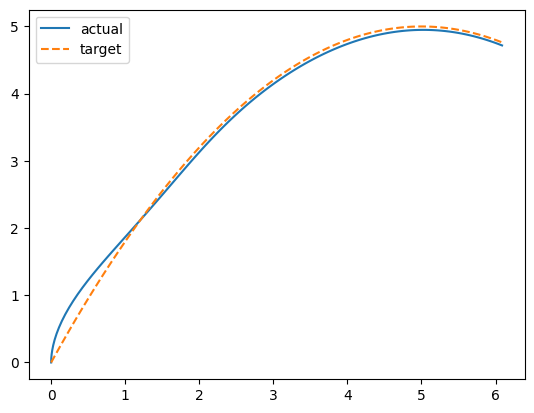

In [46]:
# convert the histories to numpy for easy lookup
p_hist = np.array(p_hist)
u_hist = np.array(u_hist)

print(f"History length: {p_hist.shape[0]}")

fig, ax = plt.subplots()

num_hist_samples = p_hist.shape[0]

display(num_hist_samples)

ax.plot(p_hist[:, 0], p_hist[:, 1], label="actual")
ax.plot(x_traj[:num_hist_samples], y_traj[:num_hist_samples], "--", label="target")
ax.legend()

In [8]:
x_err = p_hist[:, 0] - x_traj[:num_hist_samples]
y_err = p_hist[:, 1] - y_traj[:num_hist_samples]
theta_err = p_hist[:, 2] - theta_traj[:num_hist_samples]

display(x_err)
display(y_err)
display(theta_err)

array([ 0.        , -0.05020684, -0.09982422, -0.14757601, -0.19184658,
       -0.23103821, -0.26382507, -0.28930625, -0.30706708, -0.31716526,
       -0.32006344, -0.31653149, -0.30753908, -0.29415419, -0.2774575 ,
       -0.25847696, -0.23814328, -0.21726378, -0.1965114 , -0.17642501,
       -0.1574173 , -0.13978746, -0.12373613, -0.10938102, -0.09677199,
       -0.08590488, -0.0767337 , -0.06918115, -0.06314731, -0.05851694,
       -0.05516528, -0.05296269, -0.0517784 , -0.05148346, -0.05195299,
       -0.05306796, -0.0547165 , -0.05679487, -0.05920815, -0.06187062,
       -0.06470593, -0.0676471 , -0.07063635, -0.07362477, -0.07657188,
       -0.07944512, -0.08221925, -0.08487568, -0.08740184, -0.08979043,
       -0.09203877, -0.09414807, -0.0961228 , -0.09797003, -0.09969887,
       -0.10131992, -0.10284477, -0.10428557, -0.10565462, -0.10696403,
       -0.10822545, -0.10944985, -0.11064728, -0.11182674, -0.11299606,
       -0.11416181, -0.11532926, -0.11650233, -0.11768358, -0.11

array([ 0.00000000e+00, -9.00617513e-02, -1.59740564e-01, -2.10651146e-01,
       -2.45073430e-01, -2.65384049e-01, -2.74028761e-01, -2.73447049e-01,
       -2.65972475e-01, -2.53734338e-01, -2.38580438e-01, -2.22031527e-01,
       -2.05269153e-01, -1.89152028e-01, -1.74252638e-01, -1.60905090e-01,
       -1.49256334e-01, -1.39314946e-01, -1.30993929e-01, -1.24145849e-01,
       -1.18590132e-01, -1.14133178e-01, -1.10582431e-01, -1.07755652e-01,
       -1.05486575e-01, -1.03627937e-01, -1.02052671e-01, -1.00653823e-01,
       -9.93436447e-02, -9.80521919e-02, -9.67255280e-02, -9.53237728e-02,
       -9.38191757e-02, -9.21941517e-02, -9.04394325e-02, -8.85523583e-02,
       -8.65353370e-02, -8.43944876e-02, -8.21384824e-02, -7.97775604e-02,
       -7.73227219e-02, -7.47850806e-02, -7.21753556e-02, -6.95034916e-02,
       -6.67783694e-02, -6.40076174e-02, -6.11974919e-02, -5.83528168e-02,
       -5.54769803e-02, -5.25719554e-02, -4.96383601e-02, -4.66755447e-02,
       -4.36816859e-02, -

array([ 1.57079633,  0.4567253 ,  0.43368717,  0.39809004,  0.35338677,
        0.30267932,  0.24868133,  0.19370272,  0.13965215,  0.08805334,
        0.04007121, -0.00345536, -0.04197701, -0.07519576, -0.1030269 ,
       -0.12556212, -0.14303462, -0.15578697, -0.16424181, -0.1688759 ,
       -0.17019736, -0.16872629, -0.16497847, -0.15945216, -0.15261769,
       -0.14490965, -0.13672133, -0.12840123, -0.12025132, -0.11252681,
       -0.1054371 , -0.0991478 , -0.09378346, -0.08943092, -0.08614303,
       -0.08394262, -0.0828266 , -0.08276994, -0.08372967, -0.08564866,
       -0.08845902, -0.09208535, -0.09644766, -0.10146386, -0.10705196,
       -0.11313195, -0.11962728, -0.12646611, -0.1335822 , -0.14091555,
       -0.14841284, -0.15602761, -0.1637203 , -0.1714581 , -0.17921469,
       -0.18696992, -0.1947093 , -0.20242361, -0.21010832, -0.21776303,
       -0.22539099, -0.23299848, -0.2405944 , -0.24818968, -0.25579689,
       -0.2634298 , -0.27110301, -0.27883158, -0.28663079, -0.29